<a href="https://colab.research.google.com/github/LiaIssakov/Portfolio_2025/blob/main/high_dimensional_gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multidimensional gradient descent and numerical optimization

The main idea is to minimize a function $\mathbb{R^d} \to \mathbb{R}$.

> Surprisingly, it's related to our story about a wandering bacterium.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import scipy.optimize as opt

# just a technicality
import ipywidgets as widgets

In [ ]:
np.random.seed(234)
r = np.random.randn()*5
def fun(XY):
  # nothing to see
                                                                                                                                                                                                                    X,Y = XY
                                                                                                                                                                                                                    A = (X+Y)/np.sqrt(2)
                                                                                                                                                                                                                    B = (X-Y)/np.sqrt(2)
                                                                                                                                                                                                                    return (A-0.8)**2 + (2*B-0.5)**2 + r

# Part 1: Optimizing a 2-parameter function by hand

We have an 'unknown' convex function $fun: \mathbb{R}^2 \to \mathbb{R}$. We will try to optimize it by just looking at its values at different points $(x,y)$.

> If you don't remember what convexity means: for now just keep in mind it means that if we find a local minimum it means we also found the global minimum. (If all important functions were convex, our like would be easier.)

## Quick tasks:
- Play with the 2 sliders below. They control the x,y arguments passed to the function $fun$, which returns a real value. Try to **minimize** this function.

> There is a global minimum and you can get it with the sliders.

- Can you formulate an algorithm which someone else could follow? Keep in mind that sliding wildly could be very costly! Ideally you'd only use local information.

- Do you think your algorithm would also work for any number of dimensions (not just 2)? For example our favourite for 784?

In [ ]:
sl = lambda x : widgets.FloatSlider(value=x, min=-2, max=2, step=0.01)

history_of_manual_controls = []

def vis(x,y):
  history_of_manual_controls.append((x,y))
  v = fun([x,y])
  print("current value:", np.round(v,5), 'it increased :(' if v > vis.last else 'it decreased :)')
  vis.last = v

vis.last = 0

a, b = -1.5, 1.5
interactive_plot = widgets.interactive(vis, x=sl(a), y=sl(b))
widgets.HBox([interactive_plot])

# Part 2 (nothing to code): Visualization of gradient descent in 2D

We can now visualize what you did, and also how a basic gradient descent would work here.

> For now you can just look at the picture. We may get back to this after we talk more about the mathematics in the 1D case below.

Note that we can numerically approximate the partial derivatives -- and hence the gradient.





# The Loss landscape

Often we will be minimizing a certain **loss function** -- and it's useful to think about the **loss landscape**. In 2D you can really think about it as hills (high values) and valleys (low values).

> In this language, the goal is to find a path from your starting point to the lowest possible point in this landscape.

> We saw one loss function already -- the qulity of tSNE embedding is one example!

In [ ]:
# raise Exception("hey, comment me out ### once you're done with the sliders")

def grad(f, x, y, d=1e-8):
  dfdx = (f((x+d,y)) - f((x, y))) / d # !!!
  dfdy = (f((x,y+d)) - f((x, y))) / d # !!!
  return np.array([dfdx, dfdy])

In [ ]:
def grad_descent(f, p0, n_iters=1000, learning_rate=1e-2):
  p = np.asarray(p0)
  h = [p]
  for _ in range(n_iters):
    g = grad(f, *p)
    p = p - g*learning_rate # !!!
    h.append(p)
  return np.array(h)

In [ ]:
history_of_descent = grad_descent(fun, (a,b))

In [ ]:
fun(history_of_descent[-1])

np.float64(4.093958096233827)

(np.float64(-3.0),
 np.float64(2.9899999999998723),
 np.float64(-3.0),
 np.float64(2.9899999999998723))

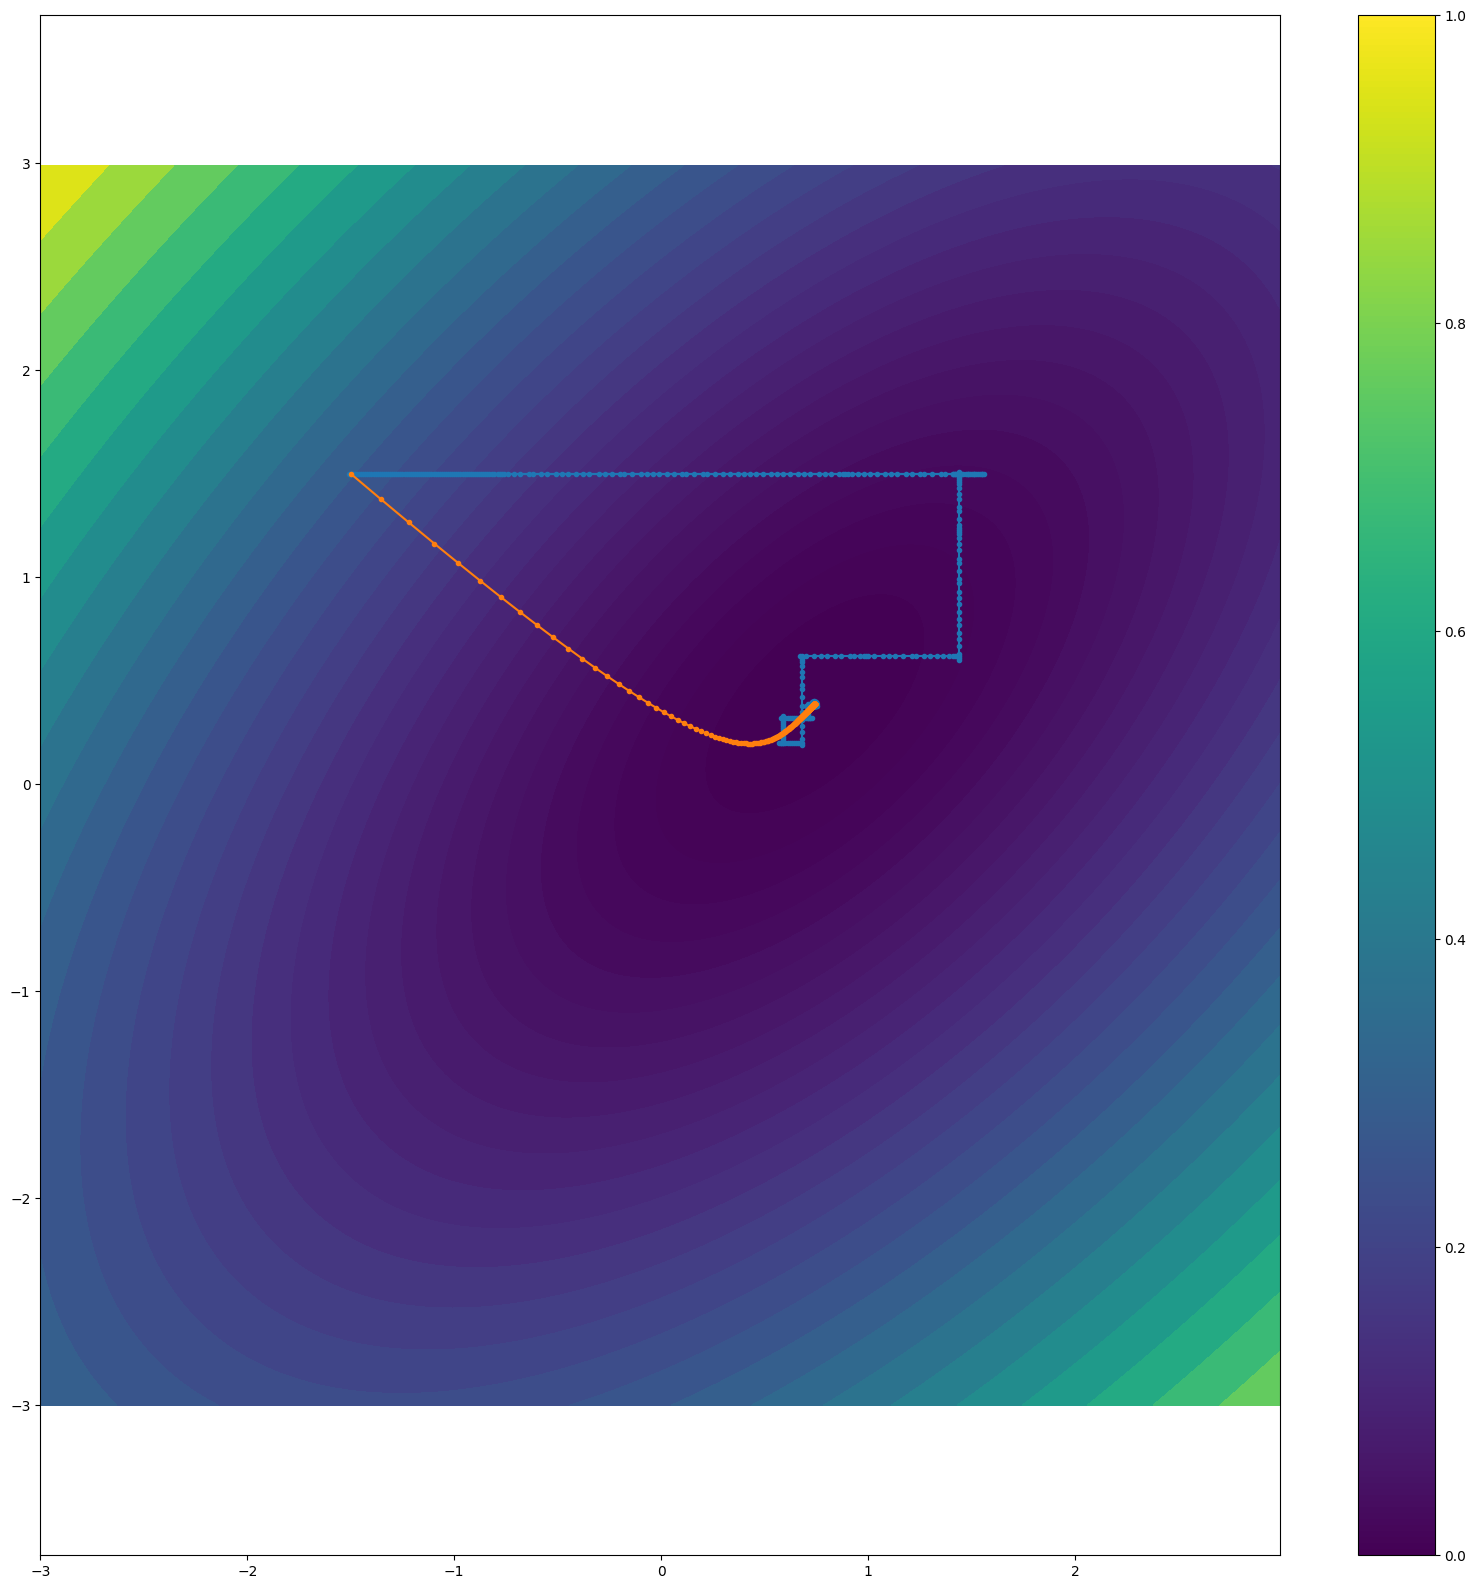

In [ ]:
plt.figure(figsize = (20,20))

x = np.arange(-3.0, 3.0, 0.01)
y = np.arange(-3.0, 3.0, 0.01)
X, Y = np.meshgrid(x, y)
Z = fun((X,Y))

history_of_manual_controls_arr = np.asarray(history_of_manual_controls)
plt.contourf(X,Y,Z, levels = np.geomspace(Z.min(),Z.max(),30))
plt.plot(*history_of_manual_controls_arr.T, '.-')
plt.scatter(*history_of_manual_controls_arr[-1].T, s = 50)
plt.plot(*history_of_descent.T, '.-')
plt.colorbar()
plt.axis('equal')

In [ ]:
# print(opt.minimize(fun, x0 = (0,0)))

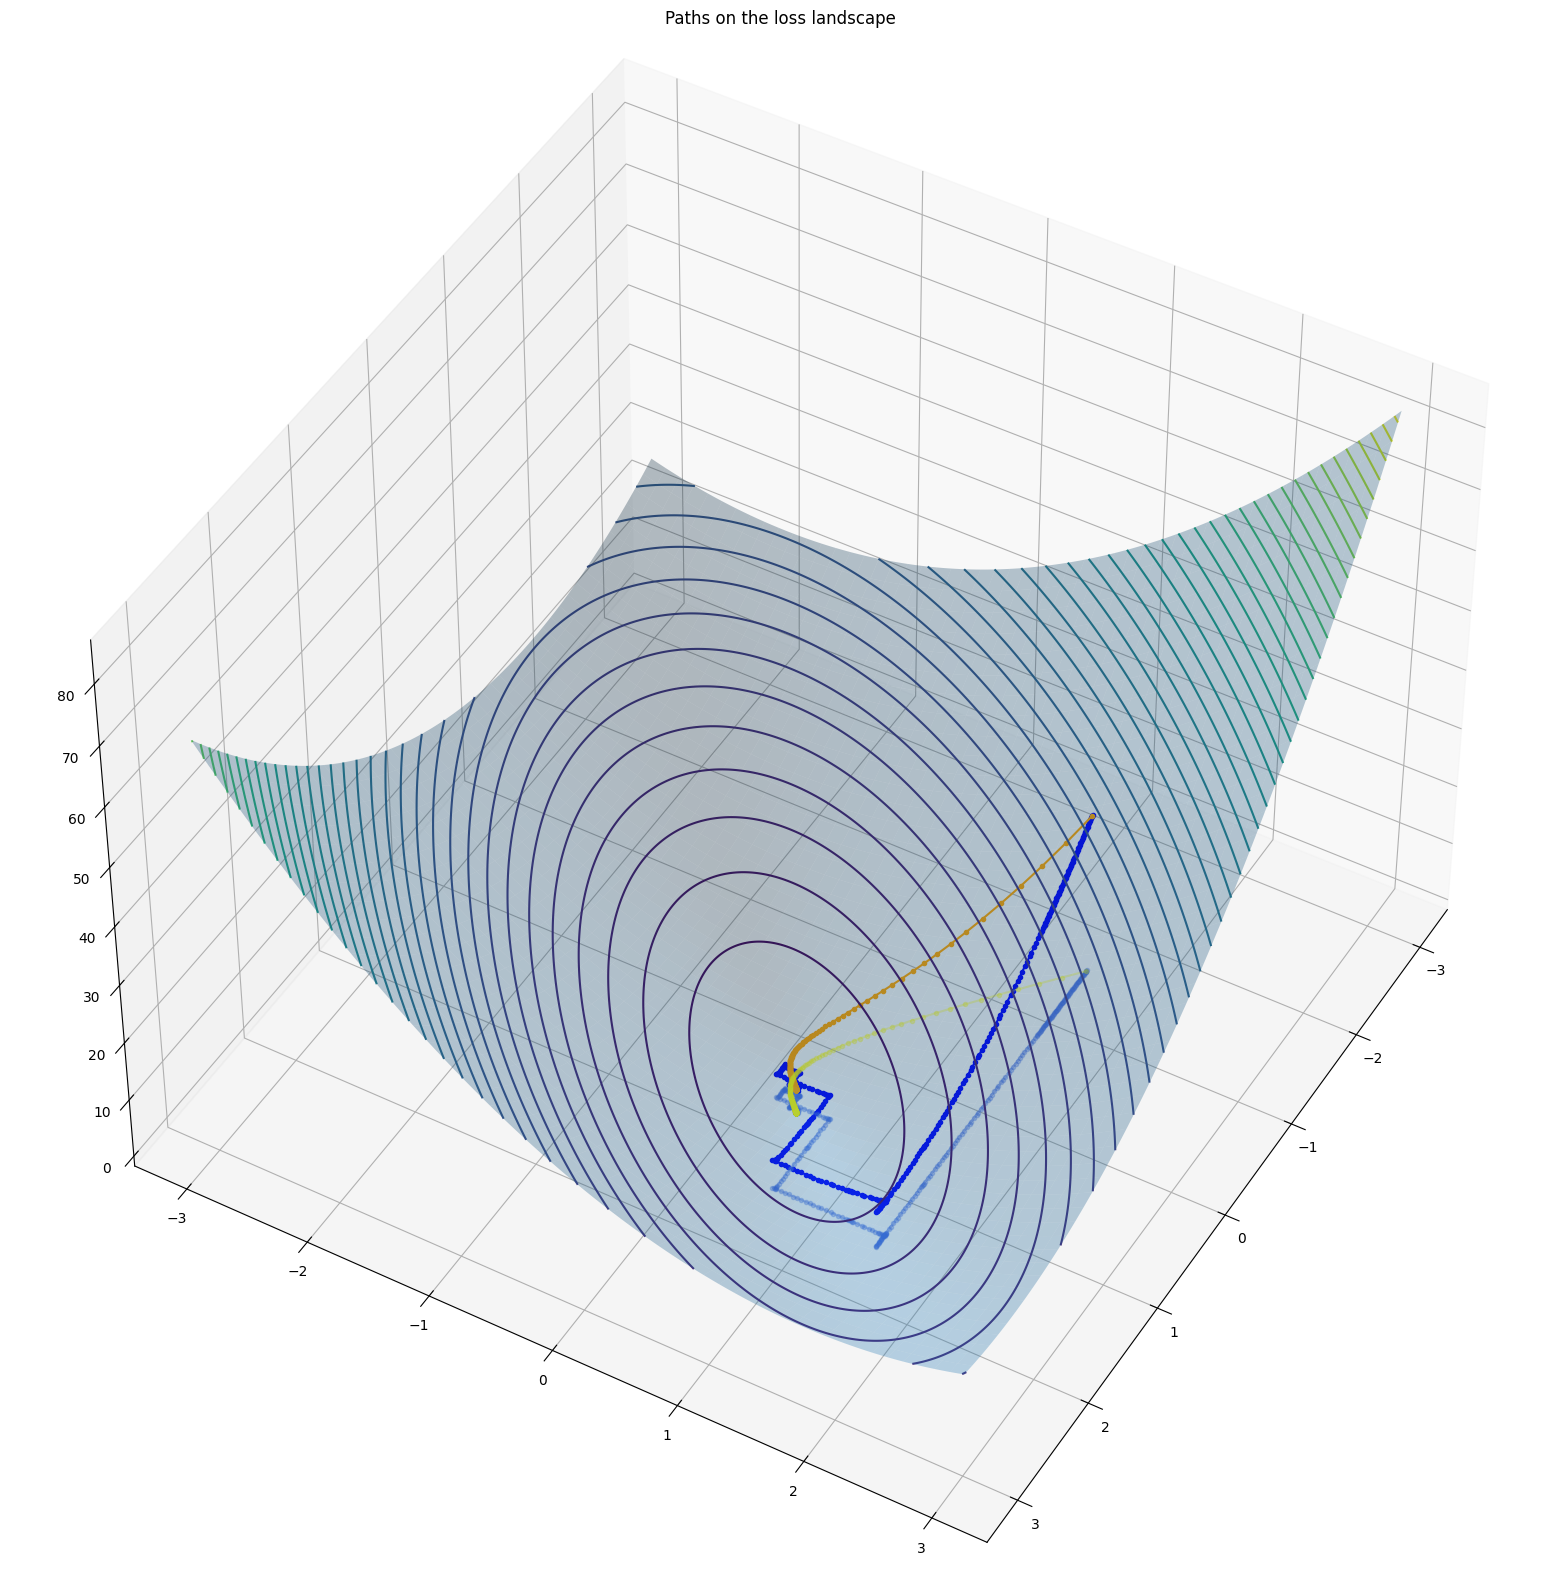

In [ ]:
fig = plt.figure(figsize = (20,20))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, alpha=0.3)
ax.contour3D(X, Y, Z, 50)
HZ = fun(history_of_descent.T)

HZman = fun(history_of_manual_controls_arr.T)

plt.title('Paths on the loss landscape')

ax.plot3D(*history_of_manual_controls_arr.T, HZman, '.-', c='blue')
ax.plot3D(*history_of_manual_controls_arr.T, 0, '.-', c='royalblue', alpha=0.3)

ax.plot3D(*history_of_descent.T, HZ, '.-', c='orange')
ax.plot3D(*history_of_descent.T, 0, '.-', c='yellow', alpha=0.3)
ax.view_init(45, 30)

#ax.contourf3D(X, Y, Z, 50, cmap='binary')

# Reminder about gradients

Let's say we have a real-valued function $f : \mathbb{R}^d \to \mathbb{R}$. So we can evaluate it with $d$ numbers like this: $f(x_1, x_2, \dots, x_d)$, or $f(p)$, where $p \in \mathbb{R}^d$.

> So it's a function which takes an $d$-dimensional vector and spits out a number.

Its partial derivatives are $\frac{\partial f}{\partial x_i} = \lim_{r \to 0}\left(\frac{f(x_1, x_2, \dots, x_i+r, \dots, x_d)-f(x_1, x_2, \dots, x_i, \dots, x_d)}{r}\right)$.

> So we just wiggle the $i$-th element of the vector and see how the function values change.

Recall that gradient is just a vector of partial derivatives.

$\nabla  f = \big[\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \dots, \frac{\partial f}{\partial x_d}\big]^T$

> Unless you're seriously into math, it's a little bit of a strange object. It's often more practical to think about the gradient at a specific point $p$. So we evaluate each partial derivative at this point $p = (p_1, p_2, ..., p_d)$ -- which gives us a vector in $\mathbb{R^d}$:

$\nabla  f(p_1, p_2, ..., p_d) = \nabla  f(p) = (\nabla  f)(p) = [\frac{\partial f}{\partial x_1}(p), \frac{\partial f}{\partial x_2}(p), \dots, \frac{\partial f}{\partial x_d}(p)]^T \in \mathbb{R^d}, e.g. [0.2, 0.6, -0.1, ..., 0.11]$

Conveniently, $\nabla  f(p)$ points in the direction of **steepest ascent**. Namely it tells us which direction will result in the greatest incease of function value.

> Can you prove this fact?

It's not hard to imagine that following the negative gradient will lead to **steepest descent**. Namely we will follow $-v$ when v is the gradient at some the current point .

> Is there a direction in which the function would not change at all?

> BTW. Do you ski? Like on snow?

# Gradient descent in higher dimensions

## Task 3
Your algorithm should also work in arbitrary dimension. Let's try 5.

Of course we can't really visualize the loss landscape in this case -- it'd live in dimension 6.

In [ ]:
history_of_manual_controls = []

sl = lambda x : widgets.FloatSlider(value=x, min = 0, max = 1, step = 0.01)

n = 5

np.random.seed(0)
v = np.random.rand(n)

def fun2(x):
  return ((x-v)@(x+x**4)).sum()

def vis(a,b,c,d,e):
  x = np.array([a,b,c,d,e])
  history_of_manual_controls.append(x)
  v = fun2(x)
  print("value:", np.round(v,5), '... increased :(' if v > vis.last else 'decreased :)')
  vis.last = v

vis.last = 0

x0 = np.random.rand(n)
a,b,c,d,e = [sl(v) for v in x0]

interactive_plot = widgets.interactive(vis, a=a, b=b, c=c, d=d, e=e)
widgets.HBox([interactive_plot])

In [ ]:
# min value should be around -0.4

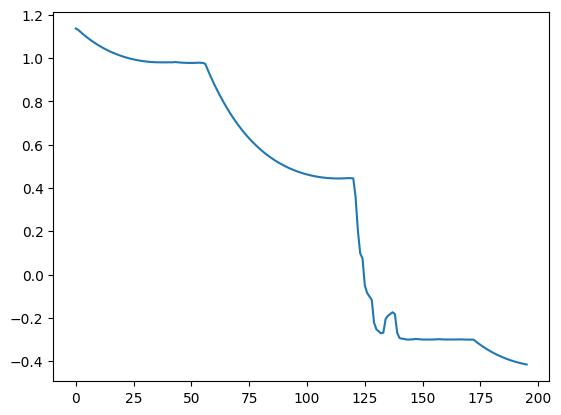

In [ ]:
plt.plot([fun2(x) for x in history_of_manual_controls])

## Example - optimizing the position of a single point (revisited)

>Consider a set of points $P$ and a point $x$. We can compute $s(x)$ as the sum of SQUARED Euclidean distances from each point in $p$ to $x$.

Let's try to verify that the arithmetic mean of $P$ is the point which minimizes $s(x)$ (among all possible points).

Can we do this in higher dimension $d$ (except for plotting)?

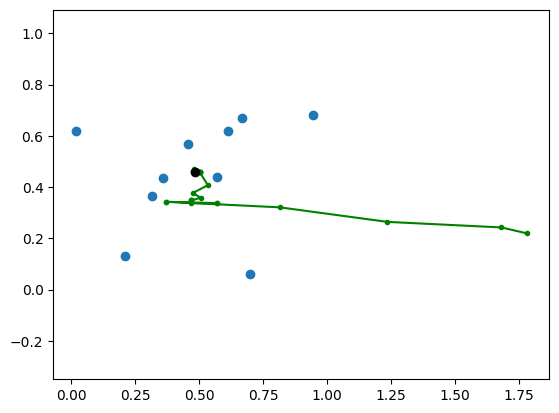

In [ ]:
n = 10
P = np.random.rand(n, 2) # some random points

def s(x):
  '''The function to minimize
  It should compute the sum of some kind of distances
  from each point in p to the current x.

  Remember you can use other variables such as P in here!
  '''
  return np.sum(np.linalg.norm(P - x, axis=1))

trail = []

# OPTIONAL!
def cb(x):
  '''Just an extra function which will be called
  for each iteration during minimization.'''
  trail.append(x)

mean = P.mean(axis=0)

x0 = np.random.rand(2)*2

method = 'Nelder-Mead' # just one particular optimization method
optimization_result = opt.minimize(s, x0, callback=cb, method=method)

'''opt.minimize returns an object with many fields/variables
  this is how we get the final result
  it often makes sense to print the whole result,
  check for errors etc'''
best_x = optimization_result.x

trail = np.array(trail)

plt.plot(*trail.T, 'g.-')
plt.scatter(*P.T)
plt.axis('equal')
plt.scatter(*mean, color='black', zorder=100);

## Task: Optimizing positions of many points

It's much easier to think about optimizing a single point/vector --
but often we will have to optimize $n$ points/vectors in $\mathbb{R^d}$. This is the case for tSNE.

> A useful trick is to 'mentally reshape' the data as a long vector in $\mathbb{R^{nd}}$.

> If the dimension of this vector scares you -- remember that this vector is just a bunch of numbers. And all we're doing is decide if each of these numbers should **go up or down for our function to decrease**. Just like we did with the 2 sliders at the beginning. Having 3 or 4 or 4_000_000_000 sliders doesn't *really* change anything, it'll just be slower!

Let's try to set it up, so that the points will end up on a circle.

> It's totally possible that all points would get e.g. clamped to a single point with norm 1. In this case we may have to regularize it -- namely add another term to our loss (so then we'd minimize the sum of two things).


In [ ]:
n = 20

from sklearn.metrics import pairwise_distances # could be useful

def loss(X):
  '''The loss function to minimize.

  It's meant to arrange points on a unit circle
  centered at the origin.

  Note that it takes a flat vector X of size n*2.
  But we interpret it as an array.
  Namely: an array of n 2-dimensional vectors.

  So technically the minimization below tunes
  a vector of size n*2, and doesn't have to know
  how we really interpret this data.
  '''
  # X is a vector of some dimension, since this function
  # takes vectors
  PS = X.reshape(n, 2) #

  # let's say we only require that the norm is close to 1
  B = np.abs(1 - np.linalg.norm(PS, axis=1)).mean()

  # You can play with different ideas
  # DS = pairwise_distances(PS) # could be useful
  return B

x0 = np.random.randn(n, 2).flatten() + 2

def cb(X):
  '''This is what we do after each iteration of our
  numerical minimization'''
  PS = X.reshape(n, 2)
  plt.scatter(*PS.T)
  plt.title(loss(X))
  plt.xlim(0,1)
  plt.ylim(0,1)
  plt.axis('equal')
  plt.show()

optimization_result = opt.minimize(loss, x0, callback = cb,
                                   options = {'maxiter':250})
best_x = optimization_result.x.reshape(n, 2)